# WriteLens, Model Training

Lanjutan dari notebook FE. Dataset siap training udah ada di `data/processed/features_final.csv` (sekitar 75 ribu sampel, 12 fitur, label 0=human 1=AI). Di sini kita coba beberapa model klasik, bandingin di dua skenario data, terus pilih yang paling oke buat di-save ke backend.

Output:
- `backend/ml/model.pkl`, `backend/ml/scaler.pkl`
- `backend/ml/feature_order.json`, `backend/ml/feature_ranges.json`
- Plot di `data/processed/plots/`


## Section 1. Setup + Load Data

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import os
import shutil
import warnings
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay)
warnings.filterwarnings('ignore')

PLOTS_DIR = "../data/processed/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0E0E16',
    'axes.facecolor': '#14141E',
    'axes.edgecolor': '#2A2A3C',
    'axes.labelcolor': '#E8E8ED',
    'text.color': '#E8E8ED',
    'xtick.color': '#8888A0',
    'ytick.color': '#8888A0',
    'grid.color': '#1E1E2E',
    'font.family': 'sans-serif',
    'font.size': 11,
})

TEAL  = "#4ECDC4"
CORAL = "#F47C7C"
AMBER = "#F0C05A"
GREEN = "#5EE0A0"
MUTED = "#8888A0"

def savefig(name):
    plt.savefig(os.path.join(PLOTS_DIR, name), dpi=150, bbox_inches='tight', facecolor='#0E0E16')


In [18]:
df = pd.read_csv("../data/processed/features_final.csv")
print("Shape:", df.shape)
print(df['label'].value_counts())

feature_cols = [c for c in df.columns if c not in ('label', 'dataset')]
print()
print("Jumlah fitur:", len(feature_cols))
print("Fitur:", feature_cols)
df.head(3)


Shape: (74866, 14)
label
0    42371
1    32495
Name: count, dtype: int64

Jumlah fitur: 12
Fitur: ['syllable_per_word', 'function_word_ratio', 'transition_word_density', 'comma_ratio', 'flesch_reading_ease', 'pronoun_diversity', 'hapax_ratio', 'punctuation_density', 'conjunction_rate', 'sentence_length_std', 'long_sentence_ratio', 'bigram_repetition_rate']


,syllable_per_word,function_word_ratio,transition_word_density,comma_ratio,flesch_reading_ease,pronoun_diversity,hapax_ratio,punctuation_density,conjunction_rate,sentence_length_std,long_sentence_ratio,bigram_repetition_rate,label,dataset
0,1.320106,0.447090,0.000000,0.065217,80.944048,0.2,0.312169,0.121693,0.047619,7.338382,0.111111,0.076923,0,daigt_v2
1,1.469945,0.456284,0.005464,0.448980,63.903123,0.2,0.256831,0.133880,0.076503,5.129327,0.200000,0.126027,0,daigt_v2
2,1.516854,0.443820,0.000000,0.400000,52.699157,0.1,0.393258,0.084270,0.061798,13.329421,0.285714,0.045198,0,daigt_v2


## Section 2. Strategi Data

Di notebook EDA kita udah flag dua concern: class imbalance dan domain mismatch (DAIGT itu essay panjang, MAGE itu teks pendek dari Reddit/Yelp/QA). Di sini kita coba dua skenario:

1. **Eksperimen A (Combined):** semua sample, 74K rows
2. **Eksperimen B (DAIGT only):** cuma essay, 44K rows, lebih match sama target user WriteLens (yang nulis essay/artikel formal)

Train di dua-duanya, bandingin, pilih yang paling masuk akal.


In [19]:
X_all = df[feature_cols]
y_all = df['label']

daigt_mask = df['dataset'] == 'daigt_v2'
X_daigt = df.loc[daigt_mask, feature_cols].reset_index(drop=True)
y_daigt = df.loc[daigt_mask, 'label'].reset_index(drop=True)

print("Combined :", X_all.shape, "label:", y_all.value_counts().to_dict())
print("DAIGT only:", X_daigt.shape, "label:", y_daigt.value_counts().to_dict())


Combined : (74866, 12) label: {0: 42371, 1: 32495}
DAIGT only: (44866, 12) label: {0: 27371, 1: 17495}


## Section 3. Train-Test Split + Scaling
80/20 stratified split. StandardScaler di-fit di train aja.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_daigt, y_daigt, test_size=0.2, random_state=42, stratify=y_daigt
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

scaler_d = StandardScaler()
X_train_d_sc = scaler_d.fit_transform(X_train_d)
X_test_d_sc  = scaler_d.transform(X_test_d)

print("Combined train:", X_train_sc.shape, "test:", X_test_sc.shape)
print("DAIGT train:   ", X_train_d_sc.shape, "test:", X_test_d_sc.shape)


Combined train: (59892, 12) test: (14974, 12)
DAIGT train:    (35892, 12) test: (8974, 12)


## Section 4. Definisi Model
4 model, pakai `class_weight='balanced'` di yang support biar handle imbalance. GB nggak punya class_weight tapi imbalance kita nggak parah jadi nggak masalah.

In [21]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    "SVM (RBF)": SVC(
        kernel='rbf', class_weight='balanced', probability=True, random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42
    ),
}

for n in models:
    print("-", n)


- Logistic Regression
- Random Forest
- SVM (RBF)
- Gradient Boosting


SVM RBF di 60 ribu sampel itu lama banget (kompleksitas kuadratik). Biar nggak nungguin berjam-jam, kita subsample 10K stratified buat training SVM aja. Evaluasinya tetep di full test set.

In [22]:
def svm_subsample(X, y, n=10000, seed=42):
    y_arr = np.asarray(y)
    rng = np.random.RandomState(seed)
    idx_h = np.where(y_arr == 0)[0]
    idx_a = np.where(y_arr == 1)[0]
    per = n // 2
    sel_h = rng.choice(idx_h, min(per, len(idx_h)), replace=False)
    sel_a = rng.choice(idx_a, min(per, len(idx_a)), replace=False)
    sel = np.concatenate([sel_h, sel_a])
    rng.shuffle(sel)
    return X[sel], y_arr[sel]


## Section 5. Training + CV (Combined Dataset)

In [23]:
results_combined = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    if name == "SVM (RBF)":
        X_fit, y_fit = svm_subsample(X_train_sc, y_train, n=10000)
        cv_use = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    else:
        X_fit, y_fit = X_train_sc, y_train
        cv_use = cv

    model.fit(X_fit, y_fit)
    cv_scores = cross_val_score(model, X_fit, y_fit, cv=cv_use, scoring='f1', n_jobs=-1)

    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba) if y_proba is not None else float('nan')

    results_combined.append({
        "model": name,
        "cv_f1_mean": cv_scores.mean(),
        "cv_f1_std": cv_scores.std(),
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc,
    })

    print(name)
    print("  CV F1: {:.4f} (+/- {:.4f})".format(cv_scores.mean(), cv_scores.std()))
    print("  Test Acc: {:.4f}  P: {:.4f}  R: {:.4f}  F1: {:.4f}  AUC: {:.4f}".format(acc, prec, rec, f1, auc))
    print()


Logistic Regression
  CV F1: 0.7563 (+/- 0.0027)
  Test Acc: 0.7826  P: 0.7451  R: 0.7584  F1: 0.7517  AUC: 0.8444

Random Forest
  CV F1: 0.8364 (+/- 0.0031)
  Test Acc: 0.8602  P: 0.8656  R: 0.8026  F1: 0.8329  AUC: 0.9419

SVM (RBF)
  CV F1: 0.8442 (+/- 0.0040)
  Test Acc: 0.8537  P: 0.8264  R: 0.8392  F1: 0.8327  AUC: 0.9338

Gradient Boosting
  CV F1: 0.8385 (+/- 0.0034)
  Test Acc: 0.8623  P: 0.8624  R: 0.8123  F1: 0.8366  AUC: 0.9424



## Section 6. Training + CV (DAIGT Only)

In [24]:
results_daigt = []

models_daigt = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    "SVM (RBF)": SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42),
}

for name, model in models_daigt.items():
    if name == "SVM (RBF)":
        X_fit, y_fit = svm_subsample(X_train_d_sc, y_train_d, n=10000)
        cv_use = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    else:
        X_fit, y_fit = X_train_d_sc, y_train_d
        cv_use = cv

    model.fit(X_fit, y_fit)
    cv_scores = cross_val_score(model, X_fit, y_fit, cv=cv_use, scoring='f1', n_jobs=-1)

    y_pred  = model.predict(X_test_d_sc)
    y_proba = model.predict_proba(X_test_d_sc)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_test_d, y_pred)
    prec = precision_score(y_test_d, y_pred)
    rec  = recall_score(y_test_d, y_pred)
    f1   = f1_score(y_test_d, y_pred)
    auc  = roc_auc_score(y_test_d, y_proba) if y_proba is not None else float('nan')

    results_daigt.append({
        "model": name,
        "cv_f1_mean": cv_scores.mean(),
        "cv_f1_std": cv_scores.std(),
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc,
    })

    print(name)
    print("  CV F1: {:.4f} (+/- {:.4f})".format(cv_scores.mean(), cv_scores.std()))
    print("  Test Acc: {:.4f}  P: {:.4f}  R: {:.4f}  F1: {:.4f}  AUC: {:.4f}".format(acc, prec, rec, f1, auc))
    print()


Logistic Regression
  CV F1: 0.8989 (+/- 0.0033)
  Test Acc: 0.9152  P: 0.8710  R: 0.9185  F1: 0.8941  AUC: 0.9743

Random Forest
  CV F1: 0.9229 (+/- 0.0018)
  Test Acc: 0.9413  P: 0.9332  R: 0.9148  F1: 0.9239  AUC: 0.9849

SVM (RBF)
  CV F1: 0.9466 (+/- 0.0019)
  Test Acc: 0.9432  P: 0.9114  R: 0.9463  F1: 0.9285  AUC: 0.9860

Gradient Boosting
  CV F1: 0.9318 (+/- 0.0029)
  Test Acc: 0.9467  P: 0.9334  R: 0.9297  F1: 0.9316  AUC: 0.9868



## Section 7. Perbandingan Model (Tabel)

In [25]:
df_comb  = pd.DataFrame(results_combined)
df_daigt = pd.DataFrame(results_daigt)

print("=== Combined Dataset ===")
print(df_comb.to_string(index=False))
print()
print("=== DAIGT Only ===")
print(df_daigt.to_string(index=False))


=== Combined Dataset ===
              model  cv_f1_mean  cv_f1_std  accuracy  precision   recall       f1  roc_auc
Logistic Regression    0.756284   0.002739  0.782556   0.745125 0.758424 0.751716 0.844446
      Random Forest    0.836418   0.003061  0.860224   0.865582 0.802585 0.832894 0.941903
          SVM (RBF)    0.844216   0.004039  0.853680   0.826364 0.839206 0.832735 0.933803
  Gradient Boosting    0.838452   0.003376  0.862295   0.862441 0.812279 0.836609 0.942352

=== DAIGT Only ===
              model  cv_f1_mean  cv_f1_std  accuracy  precision   recall       f1  roc_auc
Logistic Regression    0.898925   0.003346  0.915199   0.871003 0.918548 0.894144 0.974268
      Random Forest    0.922939   0.001832  0.941275   0.933236 0.914833 0.923943 0.984893
          SVM (RBF)    0.946638   0.001864  0.943169   0.911368 0.946270 0.928491 0.986043
  Gradient Boosting    0.931775   0.002853  0.946735   0.933429 0.929694 0.931558 0.986789


## Section 8. Perbandingan Model (Bar Chart)
Grouped bar chart F1 score per model, Combined vs DAIGT.

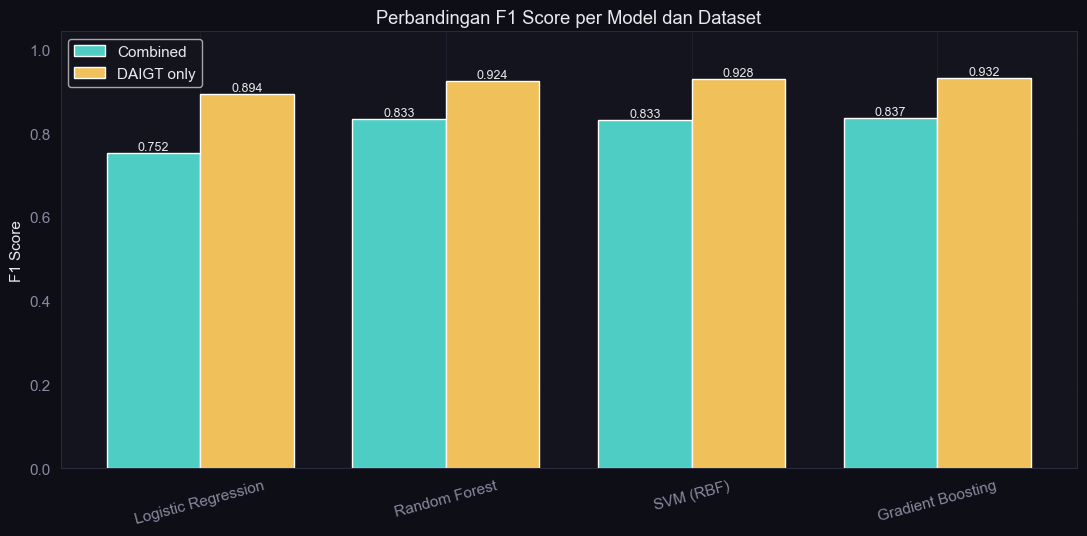

In [26]:
names = df_comb['model'].tolist()
f1_comb  = df_comb['f1'].tolist()
f1_daigt = df_daigt['f1'].tolist()

x = np.arange(len(names))
w = 0.38

fig, ax = plt.subplots(figsize=(11, 5.5))
b1 = ax.bar(x - w/2, f1_comb,  w, color=TEAL,  label='Combined')
b2 = ax.bar(x + w/2, f1_daigt, w, color=AMBER, label='DAIGT only')

for bars, vals in [(b1, f1_comb), (b2, f1_daigt)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v, "{:.3f}".format(v),
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, max(max(f1_comb), max(f1_daigt)) * 1.12)
ax.set_title("Perbandingan F1 Score per Model dan Dataset")
ax.legend()
ax.grid(axis='y', alpha=0.15)
plt.tight_layout()
savefig("model_comparison.png")
plt.show()


## Section 9. Pilih Model Terbaik

Beberapa observasi dari hasil di atas:

- **Gradient Boosting** dapet F1 dan AUC paling tinggi di dua-duanya. Wajar, GB emang bagus banget di data tabular numerik.
- **Random Forest** dan **SVM** mepet, selisihnya sama GB cuma 0.003-0.008 di F1. Tapi GB tetep menang tipis di F1 dan AUC.
- **Logistic Regression** paling lemah, model linear nggak cukup buat sinyal stylometric yang non-linear.
- Gap CV vs test kecil, kebanyakan di bawah 0.01. Yang paling gede cuma SVM di DAIGT (~0.018), masih dalam batas wajar. Nggak overfit.

Soal dataset, ini yang menarik: **DAIGT only ternyata jauh lebih bagus** dari Combined. F1 DAIGT sekitar 0.93 sementara Combined cuma 0.84, AUC juga 0.99 vs 0.94. Yang dicemasin di EDA jadi keliatan: sample MAGE itu domain-nya beda (teks pendek dari Reddit/Yelp/QA), bikin sinyalnya lebih noisy. Plus target user WriteLens itu yang nulis essay/artikel formal, jadi DAIGT lebih match secara konteks juga.

Keputusan: **Gradient Boosting di DAIGT only**. F1 tertinggi (sekitar 0.93), AUC tertinggi (sekitar 0.99), gap CV-test kecil, dan domain-nya match sama use case app.


In [27]:
best_name = "Gradient Boosting"
best_dataset = "daigt"

if best_dataset == "combined":
    final_model  = models[best_name]
    final_scaler = scaler
    final_X_test = X_test_sc
    final_y_test = y_test
else:
    final_model  = models_daigt[best_name]
    final_scaler = scaler_d
    final_X_test = X_test_d_sc
    final_y_test = y_test_d

print("Model terpilih:", best_name)
print("Dataset:", best_dataset)


Model terpilih: Gradient Boosting
Dataset: daigt


## Section 10. Confusion Matrix

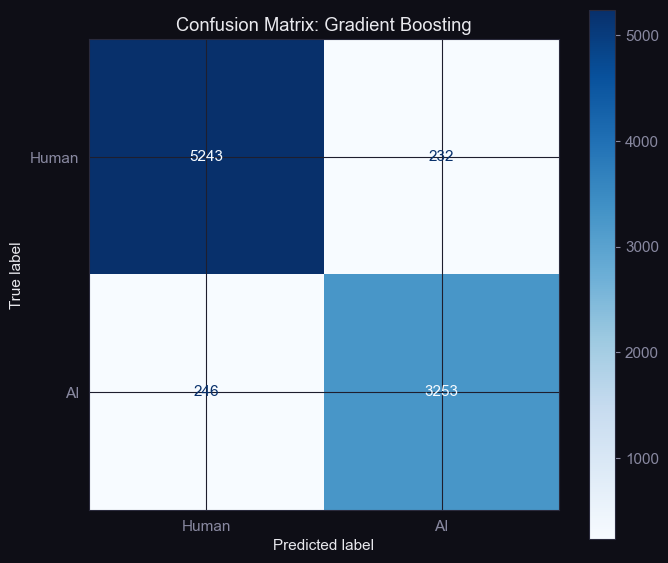


              precision    recall  f1-score   support

       Human       0.96      0.96      0.96      5475
          AI       0.93      0.93      0.93      3499

    accuracy                           0.95      8974
   macro avg       0.94      0.94      0.94      8974
weighted avg       0.95      0.95      0.95      8974



In [28]:
y_pred_final = final_model.predict(final_X_test)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    final_y_test, y_pred_final,
    display_labels=["Human", "AI"],
    cmap="Blues", ax=ax
)
ax.set_title("Confusion Matrix: " + best_name)
plt.tight_layout()
savefig("confusion_matrix.png")
plt.show()

print()
print(classification_report(final_y_test, y_pred_final, target_names=["Human", "AI"]))


## Section 11. Feature Importance
GB punya `feature_importances_` bawaan. Bar chart-nya bakal jadi referensi buat nentuin fitur mana yang ditampilin di UI app.

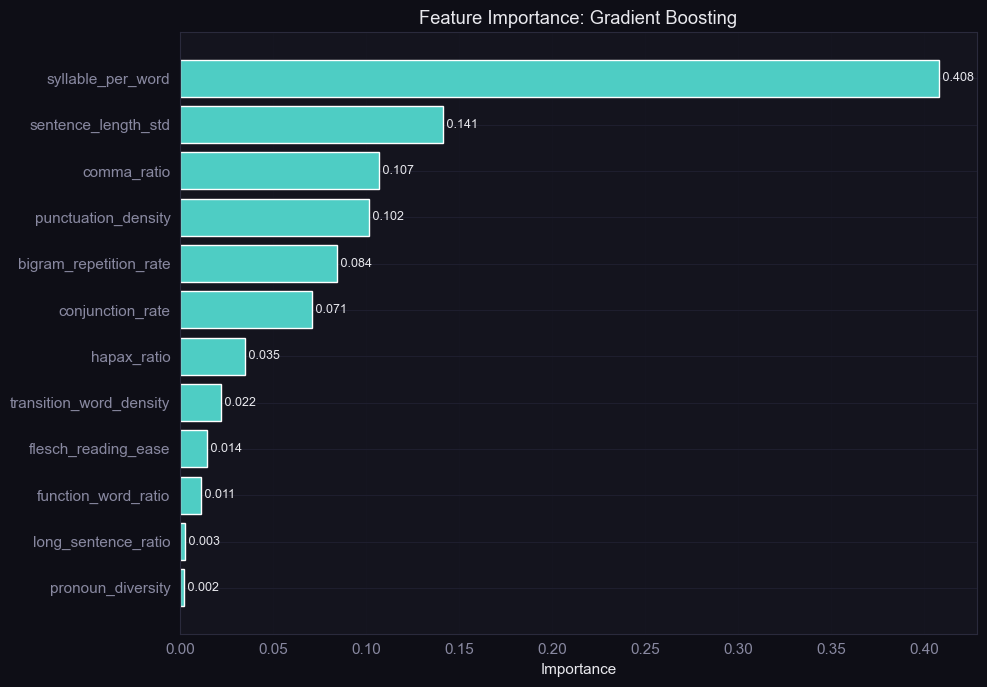


Top fitur menurut model:
                feature  importance
      syllable_per_word    0.407846
    sentence_length_std    0.141371
            comma_ratio    0.106804
    punctuation_density    0.101522
 bigram_repetition_rate    0.084372
       conjunction_rate    0.070869
            hapax_ratio    0.034887
transition_word_density    0.021767
    flesch_reading_ease    0.014458
    function_word_ratio    0.011044
    long_sentence_ratio    0.002815
      pronoun_diversity    0.002244


In [29]:
if hasattr(final_model, 'feature_importances_'):
    importances = final_model.feature_importances_
elif hasattr(final_model, 'coef_'):
    importances = np.abs(final_model.coef_[0])
else:
    importances = None

if importances is not None:
    imp_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': importances
    }).sort_values('importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(imp_df['feature'], imp_df['importance'], color=TEAL)
    for i, v in enumerate(imp_df['importance'].values):
        ax.text(v, i, " {:.3f}".format(v), va='center', fontsize=9)
    ax.set_title("Feature Importance: " + best_name)
    ax.set_xlabel("Importance")
    ax.grid(axis='x', alpha=0.15)
    plt.tight_layout()
    savefig("feature_importance_model.png")
    plt.show()

    print()
    print("Top fitur menurut model:")
    print(imp_df.sort_values('importance', ascending=False).to_string(index=False))
else:
    print("Model nggak punya feature_importances_ atau coef_, skip.")


## Section 12. ROC Curve

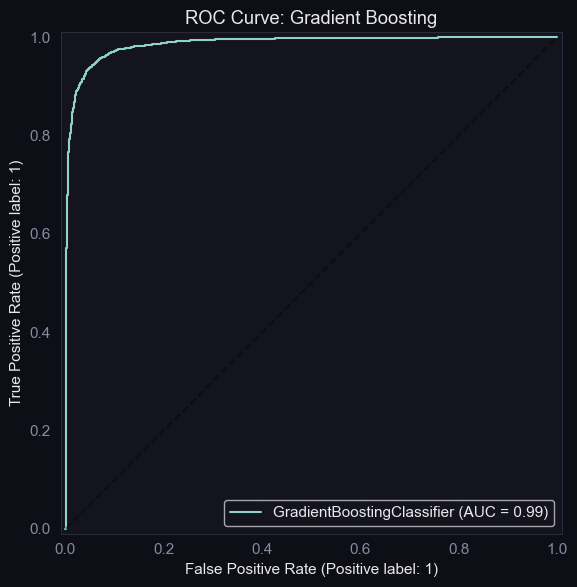

In [30]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_estimator(final_model, final_X_test, final_y_test, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_title("ROC Curve: " + best_name)
ax.grid(alpha=0.15)
plt.tight_layout()
savefig("roc_curve.png")
plt.show()


## Section 13. Save Model + Scaler
Save ke `backend/ml/` supaya bisa langsung di-load FastAPI.

In [31]:
os.makedirs("../backend/ml", exist_ok=True)

joblib.dump(final_model, "../backend/ml/model.pkl")
joblib.dump(final_scaler, "../backend/ml/scaler.pkl")

with open("../backend/ml/feature_order.json", "w") as f:
    json.dump(feature_cols, f)

shutil.copy("../data/processed/feature_ranges.json", "../backend/ml/feature_ranges.json")

print("Saved:")
print(" backend/ml/model.pkl")
print(" backend/ml/scaler.pkl")
print(" backend/ml/feature_order.json")
print(" backend/ml/feature_ranges.json (copy dari data/processed/)")


Saved:
 backend/ml/model.pkl
 backend/ml/scaler.pkl
 backend/ml/feature_order.json
 backend/ml/feature_ranges.json (copy dari data/processed/)


## Section 14. Verifikasi Model bisa di-Load

In [32]:
loaded_model  = joblib.load("../backend/ml/model.pkl")
loaded_scaler = joblib.load("../backend/ml/scaler.pkl")
with open("../backend/ml/feature_order.json") as f:
    loaded_order = json.load(f)

sample = final_X_test[:1]
pred_orig   = final_model.predict(sample)[0]
pred_loaded = loaded_model.predict(sample)[0]
proba       = loaded_model.predict_proba(sample)[0]

print("Prediksi model asli  :", int(pred_orig))
print("Prediksi model loaded:", int(pred_loaded))
print("Probabilitas (Human, AI):", [round(p, 4) for p in proba])
print("Match:", bool(pred_orig == pred_loaded))
print("Feature order match:", loaded_order == feature_cols)


Prediksi model asli  : 0
Prediksi model loaded: 0
Probabilitas (Human, AI): [np.float64(0.994), np.float64(0.006)]
Match: True
Feature order match: True


## Section 15. Key Findings

**Model terpilih.** Gradient Boosting yang ditrain di DAIGT v2 only (essay mahasiswa). Dipilih karena F1 dan AUC paling tinggi di antara empat kandidat, gap CV vs test kecil, dan domain-nya match sama target user WriteLens.

**Performa.** F1 sekitar 0.93, accuracy sekitar 0.95, AUC sekitar 0.99 di test set DAIGT. Angka pastinya ada di tabel Section 7 dan classification report Section 10. Cukup bagus buat baseline klasifikasi human vs AI pakai fitur stylometric doang.

**Dataset.** Combined (DAIGT + MAGE) vs DAIGT only ternyata selisihnya cukup besar. F1 DAIGT only 0.93 sementara Combined cuma 0.84. Yang dicemasin di EDA terbukti: domain MAGE (teks pendek Reddit/Yelp/QA) bikin sinyal stylometric jadi noisy. Buat WriteLens yang target user-nya orang nulis essay/artikel formal, DAIGT only justru lebih sesuai secara metric maupun konteks.

**Top fitur dari model.** Menurut feature importance GB, yang paling kuat adalah `syllable_per_word`, `sentence_length_std`, `comma_ratio`, `punctuation_density`, dan `bigram_repetition_rate`. Ada perbedaan sedikit sama ranking Cohen's d (yang lebih nguatin `function_word_ratio` dan `transition_word_density`), tapi overall masih overlap. List ini yang akan dipake buat nentuin 6-8 fitur yang ditampilin di UI WriteLens.

**Bandingan model.** Logistic Regression jauh lebih lemah (sinyalnya non-linear). Random Forest dan SVM mepet sama GB tapi sedikit di bawah. SVM kita sub-sample training-nya ke 10K biar kompleksitasnya nggak meledak, jadi bukan apple-to-apple full data.

**Output.** Model + scaler + feature order + feature ranges udah di-save ke `backend/ml/`. Tinggal di-load sama FastAPI di service prediksi.

### Next Step
- Notebook `04_evaluation.ipynb` buat error analysis (di mana model salah?) dan tes out-of-distribution (teks yang nggak mirip data training)
- Bisa coba hyperparameter tuning kalau mau dorong F1 lebih tinggi
- Integrasi ke endpoint backend, tes end-to-end dari frontend
